# Residual analysis

In [20]:
import pandas as pd
import json
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from metrics.wape import wape
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from experiments.baseline import baseline_metrics
from experiments.report import regression_report
from experiments.error_analysis import error_analysis, error_by_segment
import optuna
import numpy as np
import warnings
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.compose import TransformedTargetRegressor
import ast
import statsmodels.api as sm
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Load the transformed datasets
X_train = pd.read_csv('../data/processed/X_train_transformed.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()  # Convert to Series
X_test = pd.read_csv('../data/processed/X_test_transformed.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()  # Convert to Series

In [3]:
# Load unprocessed data
X_train_baseline = pd.read_csv('../data/before_preprocessor/X_train.csv')
X_test_baseline = pd.read_csv('../data/before_preprocessor/X_test.csv')

In [6]:
# Calculate residuals for using as a target
y_train_res = y_train - X_train['rolling_mean_2']
y_test_res = y_test - X_test['rolling_mean_2']

In [5]:
# Use selected features for modeling
with open('../configs/linear_features.json', 'r') as f:
    linear_features = json.load(f)

with open('../configs/tree_features.json', 'r') as f:
    tree_features = json.load(f)

In [12]:
# Define WAPE scorer for Optuna
wape_scorer = make_scorer(wape, greater_is_better=False)

In [26]:
# Analyze residuals 
residuals = (y_train - X_train_baseline['rolling_mean_2']).reset_index(drop=True).dropna()
print(f"STD of residuals: {residuals.std():.1f}")
print(f"STD of target:  {y_train.std():.1f}")
print(f"Proportion of explained variance: {1 - residuals.var()/y_train.var():.3f}")

STD of residuals: 416.9
STD of target:  1882.2
Proportion of explained variance: 0.951


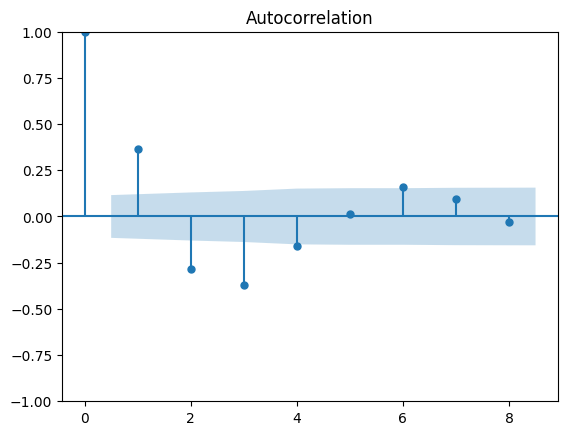

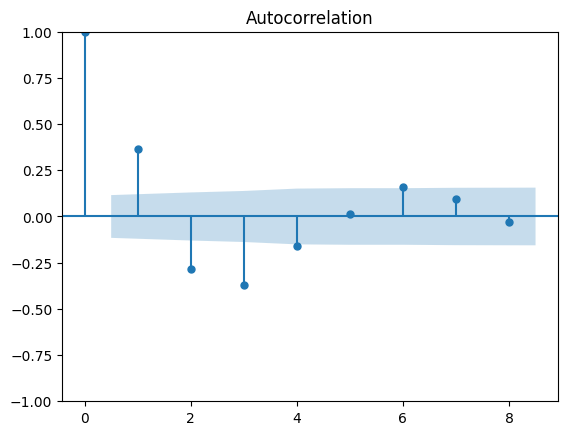

In [27]:
sm.graphics.tsa.plot_acf(residuals, lags=8)